# Task 1: Multilingual RAG (Italian)


# Imports

I kept the same environment setup and dependencies as the original notebook and modified only language-dependent components of the RAG pipeline.


In [1]:
import os

if "COLAB_GPU" in os.environ:
    print("[INFO] Running in Google Colab, installing requirements.")
    !pip install -U torch # requires torch 2.1.1+ (for efficient sdpa implementation)
    !pip install PyMuPDF # for reading PDFs with Python
    !pip install tqdm # for progress bars
    !pip install sentence-transformers # for embedding models
    !pip install accelerate # for quantization model loading
    !pip install bitsandbytes # for quantizing models (less storage space)
    !pip install flash-attn --no-build-isolation # for faster attention mechanism = faster LLM inference

[INFO] Running in Google Colab, installing requirements.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 144.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.3/39.3 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.0/90.0 kB 9.7 MB/s eta

Import PDF Document

In [2]:
# Download PDF file
import os
import requests

# Get PDF document
pdf_path = "thalion-2565-6434-1-CE.pdf"

# Download PDF if it doesn't already exist
if not os.path.exists(pdf_path):
  print("File doesn't exist, downloading...")

  # The URL of the PDF you want to download
  #url = "https://pressbooks.oer.hawaii.edu/humannutrition2/open/download?type=pdf"
  url = "https://disegnarecon.unibo.it/article/view/2565/1943"

  # The local filename to save the downloaded file
  filename = pdf_path

  # Send a GET request to the URL
  response = requests.get(url)

  # Check if the request was successful
  if response.status_code == 200:
      # Open a file in binary write mode and save the content to it
      with open(filename, "wb") as file:
          file.write(response.content)
      print(f"The file has been downloaded and saved as {filename}")
  else:
      print(f"Failed to download the file. Status code: {response.status_code}")
else:
  print(f"File {pdf_path} exists.")

File doesn't exist, downloading...
The file has been downloaded and saved as thalion-2565-6434-1-CE.pdf


In [3]:
# Requires !pip install PyMuPDF, see: https://github.com/pymupdf/pymupdf
#import fitz # (pymupdf, found this is better than pypdf for our use case, note: licence is AGPL-3.0, keep that in mind if you want to use any code commercially)
import fitz
from tqdm.auto import tqdm # for progress bars, requires !pip install tqdm

def text_formatter(text: str) -> str:
    """Performs minor formatting on text."""
    cleaned_text = text.replace("\n", " ").strip() # note: this might be different for each doc (best to experiment)

    # Other potential text formatting functions can go here
    return cleaned_text

# Open PDF and get lines/pages
# Note: this only focuses on text, rather than images/figures etc
def open_and_read_pdf(pdf_path: str) -> list[dict]:
    """
    Opens a PDF file, reads its text content page by page, and collects statistics.

    Parameters:
        pdf_path (str): The file path to the PDF document to be opened and read.

    Returns:
        list[dict]: A list of dictionaries, each containing the page number
        (adjusted), character count, word count, sentence count, token count, and the extracted text
        for each page.
    """
    doc = fitz.open(pdf_path)  # open a document
    pages_and_texts = []
    for page_number, page in tqdm(enumerate(doc)):  # iterate the document pages
        text = page.get_text()  # get plain text encoded as UTF-8
        text = text_formatter(text)
        pages_and_texts.append({
                                #"page_number": page_number - 41,  # adjust page numbers since our PDF starts on page 42
                                "page_number": page_number - 3,
                                "page_char_count": len(text),
                                "page_word_count": len(text.split(" ")),
                                "page_sentence_count_raw": len(text.split(". ")),
                                "page_token_count": len(text) / 4,  # 1 token = ~4 chars, see: https://help.openai.com/en/articles/4936856-what-are-tokens-and-how-to-count-them
                                "text": text})
    return pages_and_texts

pages_and_texts = open_and_read_pdf(pdf_path=pdf_path)
pages_and_texts[:3]

0it [00:00, ?it/s]

[{'page_number': -3,
  'page_char_count': 2886,
  'page_word_count': 422,
  'page_sentence_count_raw': 11,
  'page_token_count': 721.5,
  'text': 'TECNOLOGIE PER LA COMUNICAZIONE DEL PATRIMONIO CULTURALE dicembre 2011 ISSN 1828-5961 DISEGNARECON ALESSANDRA MESCHINI 14 | Alessandra Meschini Ricercatore di Disegno presso l’Universi\xad tà di Camerino. L’attività di ricerca degli  ultimi anni, sia nell’approccio all’attività  didattica, sia negli studi scientifici ha  riguardato in particolare le nuove forme  della rappresentazione e del rilievo co\xad erenti con lo sviluppo delle tecnologie  informatiche e le principali questioni  inerenti la documentazione dell’archi\xad tettura e dei contesti urbani. Tecnologie digitali e comunicazione dei beni culturali. Stato dell’arte e prospettive di sviluppo  Digital technology in the communication of Cultural Heritage. State of the art and potential development Tecniche di digitalizzazione di contenuti, allesti\xad mento di piattaforme di dati, p

In [4]:
import random

random.sample(pages_and_texts, k=3)

[{'page_number': 4,
  'page_char_count': 4343,
  'page_word_count': 653,
  'page_sentence_count_raw': 17,
  'page_token_count': 1085.75,
  'text': 'TECNOLOGIE PER LA COMUNICAZIONE DEL PATRIMONIO CULTURALE dicembre 2011 ISSN 1828-5961 DISEGNARECON ALESSANDRA MESCHINI Tecnologie digitali e comunicazione dei beni culturali. Stato dell’arte e prospettive di sviluppo | 21 da raggiungere: da un lato assicurare la percezione  delle particolarità architettoniche e quindi produr\xad re un modello molto dettagliato, dall’altro lato per\xad mettere agili visioni d’insieme e quindi predisporre  un modello più sintetico del contesto. È evidente  che sarà tale duplicità di requisiti richiesti a do\xad ver guidare nell’individuazione di procedimenti di  modellazione diversi ma rispondenti ad entrambi  gli obiettivi individuati per la rappresentazione  complessiva[8]. Se, invece, il proposito individuato è una model\xad lazione destinata, ad esempio, ad applicazioni di  realtà virtuale/aumentata e vir

In [5]:
import pandas as pd

df = pd.DataFrame(pages_and_texts)
df.head()

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,text
0,-3,2886,422,11,721.50,TECNOLOGIE PER LA COMUNICAZIONE DEL PATRIMONIO...
1,-2,2220,349,11,555.00,TECNOLOGIE PER LA COMUNICAZIONE DEL PATRIMONIO...
2,-1,3789,580,19,947.25,TECNOLOGIE PER LA COMUNICAZIONE DEL PATRIMONIO...
3,0,2092,302,13,523.00,TECNOLOGIE PER LA COMUNICAZIONE DEL PATRIMONIO...
4,1,3794,594,18,948.50,TECNOLOGIE PER LA COMUNICAZIONE DEL PATRIMONIO...


In [6]:
# Get stats
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count
count,11.00,11.00,11.00,11.00,11.00
mean,2.00,3454.36,526.36,21.00,863.59
std,3.32,979.20,152.26,12.21,244.80
min,-3.00,2092.00,302.00,11.00,523.00
25%,-0.50,2673.50,409.00,13.00,668.38
50%,2.00,3789.00,580.00,18.00,947.25
75%,4.50,4209.00,638.50,21.50,1052.25
max,7.00,4845.00,739.00,52.00,1211.25


SpaCy english model was replaced with an italian one to guarantee a correct segmentation of sentences for non-english documents.

In [7]:
!pip install -U spacy
!python -m spacy download it_core_news_sm

import spacy

nlp = spacy.load("it_core_news_sm")
nlp.add_pipe("sentencizer")

doc = nlp("Questa è una frase. Questa è un'altra frase.")
assert len(list(doc.sents)) == 2

list(doc.sents)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 22.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('it_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[Questa è una frase., Questa è un'altra frase.]

In [8]:
for item in tqdm(pages_and_texts):
    item["sentences"] = list(nlp(item["text"]).sents)

    # Make sure all sentences are strings
    item["sentences"] = [str(sentence) for sentence in item["sentences"]]

    # Count the sentences
    item["page_sentence_count_spacy"] = len(item["sentences"])

  0%|          | 0/11 [00:00<?, ?it/s]

In [9]:
import random

# Inspect an example
random.sample(pages_and_texts, k=1)

[{'page_number': -3,
  'page_char_count': 2886,
  'page_word_count': 422,
  'page_sentence_count_raw': 11,
  'page_token_count': 721.5,
  'text': 'TECNOLOGIE PER LA COMUNICAZIONE DEL PATRIMONIO CULTURALE dicembre 2011 ISSN 1828-5961 DISEGNARECON ALESSANDRA MESCHINI 14 | Alessandra Meschini Ricercatore di Disegno presso l’Universi\xad tà di Camerino. L’attività di ricerca degli  ultimi anni, sia nell’approccio all’attività  didattica, sia negli studi scientifici ha  riguardato in particolare le nuove forme  della rappresentazione e del rilievo co\xad erenti con lo sviluppo delle tecnologie  informatiche e le principali questioni  inerenti la documentazione dell’archi\xad tettura e dei contesti urbani. Tecnologie digitali e comunicazione dei beni culturali. Stato dell’arte e prospettive di sviluppo  Digital technology in the communication of Cultural Heritage. State of the art and potential development Tecniche di digitalizzazione di contenuti, allesti\xad mento di piattaforme di dati, p

In [10]:
df = pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,page_sentence_count_spacy
count,11.00,11.00,11.00,11.00,11.00,11.00
mean,2.00,3454.36,526.36,21.00,863.59,19.64
std,3.32,979.20,152.26,12.21,244.80,7.43
min,-3.00,2092.00,302.00,11.00,523.00,12.00
25%,-0.50,2673.50,409.00,13.00,668.38,13.50
50%,2.00,3789.00,580.00,18.00,947.25,19.00
75%,4.50,4209.00,638.50,21.50,1052.25,21.50
max,7.00,4845.00,739.00,52.00,1211.25,38.00


# Chunking

Since Italian sentences tend to be longer than English ones, the
number of sentences per chunk was reduced to maintain comparable chunk sizes in terms of token length.


In [11]:
# Italian sentences are longer
num_sentence_chunk_size = 3

# Create a function that recursively splits a list into desired sizes
def split_list(input_list: list,
               slice_size: int) -> list[list[str]]:
    """
    Splits the input_list into sublists of size slice_size (or as close as possible).

    For example, a list of 17 sentences would be split into two lists of [[10], [7]]
    """
    return [input_list[i:i + slice_size] for i in range(0, len(input_list), slice_size)]

# Loop through pages and texts and split sentences into chunks
for item in tqdm(pages_and_texts):
    item["sentence_chunks"] = split_list(input_list=item["sentences"],
                                         slice_size=num_sentence_chunk_size)
    item["num_chunks"] = len(item["sentence_chunks"])

  0%|          | 0/11 [00:00<?, ?it/s]

In [12]:
# Sample an example from the group (note: many samples have only 1 chunk as they have <=10 sentences total)
random.sample(pages_and_texts, k=1)

[{'page_number': 2,
  'page_char_count': 2646,
  'page_word_count': 410,
  'page_sentence_count_raw': 13,
  'page_token_count': 661.5,
  'text': 'TECNOLOGIE PER LA COMUNICAZIONE DEL PATRIMONIO CULTURALE dicembre 2011 ISSN 1828-5961 DISEGNARECON ALESSANDRA MESCHINI Tecnologie digitali e comunicazione dei beni culturali. Stato dell’arte e prospettive di sviluppo | 19 procedurali, individuabili e raggiungibili non senza  fatica, consentono però quella ricercata agevola\xad zione della fruizione della scena 3D, nonché ot\xad timizzazione della visualizzazione, permettendo  anche quel grado di flessibilità e adattabilità dei  dati a cambiamenti, miglioramenti, aggiornamenti  eventualmente richiesti nell’applicazione digitale  predisposta[5]. Molte ancora potrebbero essere le questioni  tecnico-procedurali esemplificabili ma ciò che, in\xad vece, val la pena ancora di menzionare sono due  problematiche di fondo con le quali devono fare i  conti coloro che progettano e sviluppano percor\xad s

In [13]:
# Create a DataFrame to get stats
df = pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,page_sentence_count_spacy,num_chunks
count,11.00,11.00,11.00,11.00,11.00,11.00,11.00
mean,2.00,3454.36,526.36,21.00,863.59,19.64,7.00
std,3.32,979.20,152.26,12.21,244.80,7.43,2.49
min,-3.00,2092.00,302.00,11.00,523.00,12.00,4.00
25%,-0.50,2673.50,409.00,13.00,668.38,13.50,5.00
50%,2.00,3789.00,580.00,18.00,947.25,19.00,7.00
75%,4.50,4209.00,638.50,21.50,1052.25,21.50,7.50
max,7.00,4845.00,739.00,52.00,1211.25,38.00,13.00


In [14]:
import re

# Split each chunk into its own item
pages_and_chunks = []
for item in tqdm(pages_and_texts):
    for sentence_chunk in item["sentence_chunks"]:
        chunk_dict = {}
        chunk_dict["page_number"] = item["page_number"]

        # Join the sentences together into a paragraph-like structure, aka a chunk (so they are a single string)
        joined_sentence_chunk = "".join(sentence_chunk).replace("  ", " ").strip()
        joined_sentence_chunk = re.sub(r'\.([A-Z])', r'. \1', joined_sentence_chunk) # ".A" -> ". A" for any full-stop/capital letter combo
        chunk_dict["sentence_chunk"] = joined_sentence_chunk

        # Get stats about the chunk
        chunk_dict["chunk_char_count"] = len(joined_sentence_chunk)
        chunk_dict["chunk_word_count"] = len([word for word in joined_sentence_chunk.split(" ")])
        chunk_dict["chunk_token_count"] = len(joined_sentence_chunk) / 4 # 1 token = ~4 characters

        pages_and_chunks.append(chunk_dict)

# How many chunks do we have?
len(pages_and_chunks)

  0%|          | 0/11 [00:00<?, ?it/s]

77

In [15]:
# View a random sample
random.sample(pages_and_chunks, k=1)

[{'page_number': 7,
  'sentence_chunk': 'TECNOLOGIE PER LA COMUNICAZIONE DEL PATRIMONIO CULTURALE dicembre 2011 ISSN 1828-5961DISEGNARECON | ALESSANDRA MESCHINI Tecnologie digitali e comunicazione dei beni culturali. Stato dell’arte e prospettive di sviluppo 24 12.',
  'chunk_char_count': 224,
  'chunk_word_count': 29,
  'chunk_token_count': 56.0}]

In [16]:
# Get stats about our chunks
df = pd.DataFrame(pages_and_chunks)
df.describe().round(2)

,page_number,chunk_char_count,chunk_word_count,chunk_token_count
count,77.00,77.00,77.00,77.00
mean,2.79,485.91,68.48,121.48
std,3.17,284.48,40.12,71.12
min,-3.00,42.00,5.00,10.50
25%,0.00,273.00,37.00,68.25
50%,3.00,455.00,64.00,113.75
75%,6.00,631.00,91.00,157.75
max,7.00,1290.00,177.00,322.50


In [17]:
# Show random chunks with under 30 tokens in length
min_token_length = 30
for row in df[df["chunk_token_count"] <= min_token_length].sample(10, replace=True).iterrows():
    print(f'Chunk token count: {row[1]["chunk_token_count"]} | Text: {row[1]["sentence_chunk"]}')

Chunk token count: 14.0 | Text: le Venezie (im)possibili online.[12] L. De Luca, op.cit.
Chunk token count: 10.5 | Text: 4-5). 3. Franz Fischnaller, MultiMegaBook.
Chunk token count: 19.5 | Text: pp.177-179. Ronchi, A. M., Da “Real virtuality” alla Società della Conoscenza:
Chunk token count: 14.0 | Text: le Venezie (im)possibili online.[12] L. De Luca, op.cit.
Chunk token count: 19.5 | Text: pp.177-179. Ronchi, A. M., Da “Real virtuality” alla Società della Conoscenza:
Chunk token count: 14.0 | Text: le Venezie (im)possibili online.[12] L. De Luca, op.cit.
Chunk token count: 14.0 | Text: le Venezie (im)possibili online.[12] L. De Luca, op.cit.
Chunk token count: 10.5 | Text: 4-5). 3. Franz Fischnaller, MultiMegaBook.
Chunk token count: 14.0 | Text: le Venezie (im)possibili online.[12] L. De Luca, op.cit.
Chunk token count: 19.5 | Text: pp.177-179. Ronchi, A. M., Da “Real virtuality” alla Società della Conoscenza:


In [18]:
pages_and_chunks_over_min_token_len = df[df["chunk_token_count"] > min_token_length].to_dict(orient="records")
pages_and_chunks_over_min_token_len[:2]

[{'page_number': -3,
  'sentence_chunk': 'TECNOLOGIE PER LA COMUNICAZIONE DEL PATRIMONIO CULTURALE dicembre 2011 ISSN 1828-5961DISEGNARECON ALESSANDRA MESCHINI14 | Alessandra Meschini Ricercatore di Disegno presso l’Universi\xad tà di Camerino.',
  'chunk_char_count': 199,
  'chunk_word_count': 24,
  'chunk_token_count': 49.75},
 {'page_number': -3,
  'sentence_chunk': 'L’attività di ricerca degli ultimi anni, sia nell’approccio all’attività didattica, sia negli studi scientifici ha riguardato in particolare le nuove forme della rappresentazione e del rilievo co\xad erenti con lo sviluppo delle tecnologie informatiche e le principali questioni inerenti la documentazione dell’archi\xad tettura e dei contesti urbani. Tecnologie digitali e comunicazione dei beni culturali. Stato dell’arte e prospettive di sviluppo Digital technology in the communication of Cultural Heritage.',
  'chunk_char_count': 505,
  'chunk_word_count': 68,
  'chunk_token_count': 126.25}]

# Embedding our text chunks

The English-only embedding model was replaced with a multilingual
SentenceTransformer to support semantic retrieval over non-English documents.


In [19]:
# Requires !pip install sentence-transformers
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer(model_name_or_path="paraphrase-multilingual-mpnet-base-v2",
                                      device="cpu") # choose the device to load the model to (note: GPU will often be *much* faster than CPU)

# Create a list of sentences to turn into numbers
sentences = [
    "La libreria Sentence Transformers offre un modo semplice per creare embedding.",
    "Le frasi possono essere codificate singolarmente o in batch.",
    "Gli embedding sono uno dei concetti più potenti del machine learning.",
    "Imparare a usare bene gli embedding è fondamentale per l'AI."
]

# Sentences are encoded/embedded by calling model.encode(),
embeddings = embedding_model.encode(sentences)
embeddings_dict = dict(zip(sentences, embeddings))

# See the embeddings
for sentence, embedding in embeddings_dict.items():
    print("Sentence:", sentence)
    print("Embedding:", embedding)
    print("")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Sentence: La libreria Sentence Transformers offre un modo semplice per creare embedding.
Embedding: [ 5.43057211e-02 -2.45820254e-01 -1.25961602e-02  5.91407642e-02
  1.89146996e-02  8.31608623e-02  2.36795783e-01  5.75249791e-02
 -9.72511545e-02 -2.39256695e-02  1.54356603e-02  3.26338828e-01
 -8.50973800e-02  6.97056726e-02  1.61425974e-02 -2.34244391e-01
  1.23272739e-01  3.61116007e-02 -7.77313262e-02 -7.74780288e-04
  9.82586369e-02 -4.11499739e-02 -3.64770629e-02 -6.36732727e-02
 -1.36556864e-01 -7.54898414e-03 -1.20799363e-01  2.08596475e-02
  6.51971549e-02  7.82615468e-02  1.03691816e-01  9.35907662e-02
 -5.54441102e-02 -6.52406216e-02  6.91945329e-02 -1.67539284e-01
 -1.45920724e-01  1.19579034e-02 -1.85163662e-01 -7.74816647e-02
  6.03972189e-02  7.72662228e-03  5.46814203e-02 -4.67265770e-03
  9.78317112e-03  1.19393729e-01  1.47375584e-01 -3.17607448e-02
  1.02426589e-01  2.53583640e-02  8.68350361e-03  6.11501262e-02
  4.20037098e-02  9.26376656e-02  2.32049584e-01 -1.227

The same multilingual embedding model is used for both document chunks and user
queries to ensure consistency in the embedding space.


In [20]:
single_sentence = "Hey quanto sono utili gli embeddings?"
single_embedding = embedding_model.encode(single_sentence)
print(f"Sentence: {single_sentence}")
print(f"Embedding:\n{single_embedding}")
print(f"Embedding size: {single_embedding.shape}")

Sentence: Hey quanto sono utili gli embeddings?
Embedding:
[ 9.02012587e-02 -9.39260498e-02 -1.56466756e-02  7.84642473e-02
  7.98787549e-03  1.13434136e-01  1.03585660e-01 -4.18774448e-02
  6.54899850e-02  3.33616585e-02  6.87139407e-02  8.58317316e-02
 -5.55730350e-02  1.23997010e-01  2.39813235e-02 -7.68937767e-02
  2.00090613e-02  1.30347505e-01  1.22916640e-03  1.83713937e-03
  5.93302818e-03 -8.78520086e-02  5.91729768e-02 -1.09259365e-02
 -1.30266473e-02 -5.85850514e-02 -6.59427568e-02  7.60440528e-03
  7.43569732e-02  4.62858863e-02  1.14372335e-01 -4.27854955e-02
 -6.06137700e-02  1.15021213e-03  7.65040144e-02 -9.10796691e-03
 -7.43322372e-02  5.56621253e-02 -2.84458011e-01  1.58017308e-01
  8.94129351e-02  2.50083003e-02  6.45556226e-02 -3.96339223e-02
 -7.74599463e-02 -1.09231979e-01  5.01611941e-02 -2.16682568e-01
  9.21433866e-02 -7.43455216e-02 -2.02823859e-02  1.94677234e-01
 -7.65463933e-02  4.59947623e-02  2.77521610e-01 -7.18830898e-02
 -8.01543798e-03 -5.78197539e-0

In [21]:
%%time

# Send the model to the GPU
embedding_model.to("cuda") # requires a GPU installed

# Create embeddings one by one on the GPU
for item in tqdm(pages_and_chunks_over_min_token_len):
    item["embedding"] = embedding_model.encode(item["sentence_chunk"])

  0%|          | 0/73 [00:00<?, ?it/s]

CPU times: user 1.45 s, sys: 311 ms, total: 1.76 s
Wall time: 2.36 s


Embeddings are computed in batches for efficiency and stored for reuse. This
step is independent of the document language and was left unchanged.

In [22]:
# Turn text chunks into a single list
text_chunks = [item["sentence_chunk"] for item in pages_and_chunks_over_min_token_len]

In [23]:
%%time

# Embed all texts in batches
text_chunk_embeddings = embedding_model.encode(text_chunks,
                                               batch_size=8, # you can use different batch sizes here for speed/performance, I found 32 works well for this use case
                                               convert_to_tensor=True) # optional to return embeddings as tensor instead of array

text_chunk_embeddings

CPU times: user 531 ms, sys: 44.5 ms, total: 576 ms
Wall time: 627 ms


tensor([[-0.0772,  0.1991, -0.0120,  ...,  0.0476,  0.0997, -0.0130],
        [ 0.0062,  0.1188, -0.0186,  ...,  0.0311,  0.0110,  0.0033],
        [ 0.0037, -0.0229, -0.0156,  ..., -0.0044,  0.0110,  0.0222],
        ...,
        [-0.1363,  0.2430, -0.0066,  ...,  0.0010,  0.0521, -0.0438],
        [-0.2031,  0.2483, -0.0069,  ...,  0.0230,  0.0618, -0.0307],
        [-0.1999,  0.2660, -0.0090,  ..., -0.0005,  0.0170,  0.0054]],
       device='cuda:0')

In [24]:
# Save embeddings to file
text_chunks_and_embeddings_df = pd.DataFrame(pages_and_chunks_over_min_token_len)
embeddings_df_save_path = "text_chunks_and_embeddings_df.csv"
text_chunks_and_embeddings_df.to_csv(embeddings_df_save_path, index=False)

In [25]:
# Import saved file and view
text_chunks_and_embedding_df_load = pd.read_csv(embeddings_df_save_path)
text_chunks_and_embedding_df_load.tail()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count,embedding
68,7,"conoscenza, informazioni, formati nell’era del...",174,24,43.50,[-3.91768478e-02 1.24843968e-02 -9.30297002e-...
69,7,"Storia, tecniche, linguaggi, etiche ed estetic...",286,38,71.50,[-3.19051035e-02 2.08484128e-01 -5.22540789e-...
70,7,Design e nuove tecnologie per lo sviluppo econ...,293,40,73.25,[-1.36329770e-01 2.43012339e-01 -6.63289847e-...
71,7,Prospettive e opportunità per la valorizzazion...,775,112,193.75,[-2.03147680e-01 2.48336226e-01 -6.92337519e-...
72,7,"piazza Arringo ad Ascoli Piceno, in Gam­ barde...",287,45,71.75,[-1.99932367e-01 2.66011626e-01 -9.01212823e-...


# RAG - Search and Answer



In [26]:
import random

import torch
import numpy as np
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"

# Import texts and embedding df
text_chunks_and_embedding_df = pd.read_csv("text_chunks_and_embeddings_df.csv")

# Convert embedding column back to np.array (it got converted to string when it got saved to CSV)
text_chunks_and_embedding_df["embedding"] = text_chunks_and_embedding_df["embedding"].apply(lambda x: np.fromstring(x.strip("[]"), sep=" "))

# Convert texts and embedding df to list of dicts
pages_and_chunks = text_chunks_and_embedding_df.to_dict(orient="records")

# Convert embeddings to torch tensor and send to device (note: NumPy arrays are float64, torch tensors are float32 by default)
embeddings = torch.tensor(np.array(text_chunks_and_embedding_df["embedding"].tolist()), dtype=torch.float32).to(device)
embeddings.shape
type(embeddings)

torch.Tensor

In [27]:
text_chunks_and_embedding_df.head()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count,embedding
0,-3,TECNOLOGIE PER LA COMUNICAZIONE DEL PATRIMONIO...,199,24,49.75,"[-0.0771862864, 0.199121401, -0.0119612645, 0...."
1,-3,"L’attività di ricerca degli ultimi anni, sia n...",505,68,126.25,"[0.00620657252, 0.118799955, -0.0186250918, -0..."
2,-3,State of the art and potential development Tec...,1088,144,272.00,"[0.00373468339, -0.022923084, -0.0156433973, -..."
3,-3,"Techniques for digitalising content, organisin...",936,130,234.00,"[0.0102204736, 0.00247933622, -0.000753616448,..."
4,-2,TECNOLOGIE PER LA COMUNICAZIONE DEL PATRIMONIO...,496,68,124.00,"[-0.0275359396, 0.0131810298, -0.0141378781, -..."


In [28]:
embeddings[0]

tensor([-7.7186e-02,  1.9912e-01, -1.1961e-02,  2.7937e-02,  8.1114e-02,
         1.5936e-02,  1.6708e-01, -9.6519e-02,  8.7746e-02,  3.8518e-02,
         3.7746e-02, -8.0411e-02,  4.8663e-02,  3.8882e-02, -3.5792e-02,
        -9.5325e-02,  3.9831e-02,  6.2850e-02, -5.3536e-02,  3.4747e-02,
         8.7137e-02,  6.0537e-02,  6.2578e-02, -2.3053e-02, -3.4818e-02,
        -3.7202e-02, -9.6729e-02, -6.9361e-02,  8.4861e-02, -2.9619e-02,
         8.4983e-02,  5.3696e-02, -8.9202e-03, -4.4479e-02,  2.1555e-02,
        -1.9733e-02, -3.3365e-02, -3.5769e-02,  6.0361e-02, -1.0350e-01,
         2.6774e-01,  1.8115e-02, -3.8136e-02,  7.3749e-03, -2.1018e-01,
         1.9006e-01, -1.3353e-02, -4.2512e-02, -2.8279e-02, -1.0292e-02,
         5.1810e-02,  1.9480e-02,  5.2098e-02, -2.5824e-02,  2.4034e-02,
        -1.4045e-01, -5.8787e-02, -2.5876e-02,  8.3590e-02,  1.1704e-01,
        -8.2065e-02, -5.3716e-03, -7.3704e-04,  3.8125e-02, -1.3924e-01,
        -9.4831e-02,  8.6167e-02, -1.4070e-01,  3.3

In [30]:
from sentence_transformers import util, SentenceTransformer

embedding_model = SentenceTransformer(model_name_or_path="paraphrase-multilingual-mpnet-base-v2",
                                      device=device) # choose the device to load the model to

The retrieval step was tested using a non-English query to demonstrate the
effectiveness of multilingual embeddings in the RAG pipeline.


In [31]:
# 1. Define the query
query = "Quali sono le nuove modalità di fruizione dei beni culturali?"
print(f"Query: {query}")

# 2. Embed the query to the same numerical space as the text examples
# Note: It's important to embed your query with the same model you embedded your examples with.
query_embedding = embedding_model.encode(query, convert_to_tensor=True)

# 3. Get similarity scores with the dot product (we'll time this for fun)
from time import perf_counter as timer

start_time = timer()
dot_scores = util.dot_score(a=query_embedding, b=embeddings)[0]
end_time = timer()

print(f"Time taken to get scores on {len(embeddings)} embeddings: {end_time-start_time:.5f} seconds.")

# 4. Get the top-k results (we'll keep this to 5)
top_results_dot_product = torch.topk(dot_scores, k=5)
top_results_dot_product

Query: Quali sono le nuove modalità di fruizione dei beni culturali?
Time taken to get scores on 73 embeddings: 0.00534 seconds.


torch.return_types.topk(
values=tensor([3.6727, 3.6054, 3.5541, 3.4665, 3.4186], device='cuda:0'),
indices=tensor([ 3, 39,  4, 15, 13], device='cuda:0'))

In [32]:
larger_embeddings = torch.randn(1000*embeddings.shape[0], 768).to(device)
print(f"Embeddings shape: {larger_embeddings.shape}")

# Perform dot product across 168,000 embeddings
start_time = timer()
dot_scores = util.dot_score(a=query_embedding, b=larger_embeddings)[0]
end_time = timer()

print(f"Time take to get scores on {len(larger_embeddings)} embeddings: {end_time-start_time:.5f} seconds.")

Embeddings shape: torch.Size([73000, 768])
Time take to get scores on 73000 embeddings: 0.01866 seconds.


In [33]:
# Define helper function to print wrapped text
import textwrap

def print_wrapped(text, wrap_length=80):
    wrapped_text = textwrap.fill(text, wrap_length)
    print(wrapped_text)

In [34]:
print(f"Query: '{query}'\n")
print("Results:")
# Loop through zipped together scores and indicies from torch.topk
for score, idx in zip(top_results_dot_product[0], top_results_dot_product[1]):
    print(f"Score: {score:.4f}")
    # Print relevant sentence chunk (since the scores are in descending order, the most relevant chunk will be first)
    print("Text:")
    print_wrapped(pages_and_chunks[idx]["sentence_chunk"])
    # Print the page number too so we can reference the textbook further (and check the results)
    print(f"Page number: {pages_and_chunks[idx]['page_number']}")
    print("\n")

Query: 'Quali sono le nuove modalità di fruizione dei beni culturali?'

Results:
Score: 3.6727
Text:
Techniques for digitalising content, organising data platforms, setting up
simulations, animation and 3D reconstruction, planning user-friendly interfa­
ces, creating active and involving learning techni­ ques, or more generally,
designing multimedia/ multifunctional ways to access information have all
contributed to the redefinition of space and time as far as the transmission and
management of knowledge are concerned. Within this framework our paper proposes
a series of considerations on the relationship between digi­ tal technology and
its application in the communi­ cation of cultural heritage. Starting from
investiga­ tion of the connection between tools/procedures used and the actual
fulfilment of groundbreaking methods of communication, our study aims at
comparing the different branches of research, the areas in which the technology
needs to be applied and the requirements of cul

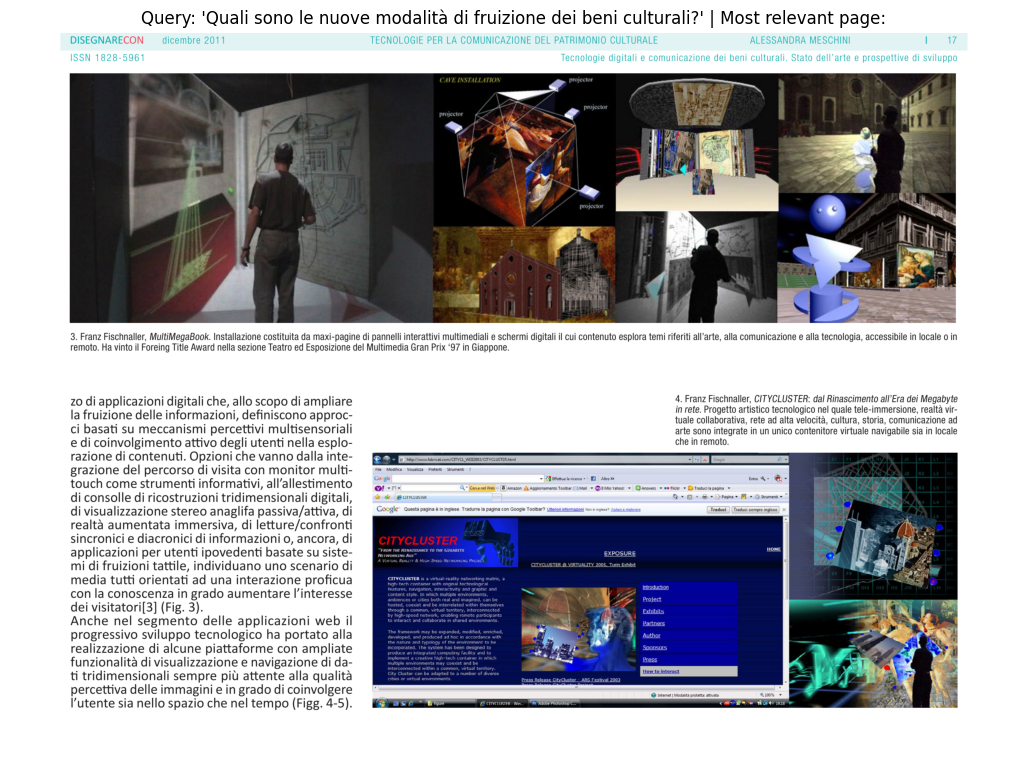

In [43]:
import fitz

# Open PDF and load target page
pdf_path = "thalion-2565-6434-1-CE.pdf"
doc = fitz.open(pdf_path)
page = doc.load_page(3)

# Get the image of the page
img = page.get_pixmap(dpi=300)

# Optional: save the image
#img.save("output_filename.png")
doc.close()

# Convert the Pixmap to a numpy array
img_array = np.frombuffer(img.samples_mv,
                          dtype=np.uint8).reshape((img.h, img.w, img.n))

# Display the image using Matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(13, 10))
plt.imshow(img_array)
plt.title(f"Query: '{query}' | Most relevant page:")
plt.axis('off') # Turn off axis
plt.show()

In [44]:
import torch

def dot_product(vector1, vector2):
    return torch.dot(vector1, vector2)

def cosine_similarity(vector1, vector2):
    dot_product = torch.dot(vector1, vector2)

    # Get Euclidean/L2 norm of each vector (removes the magnitude, keeps direction)
    norm_vector1 = torch.sqrt(torch.sum(vector1**2))
    norm_vector2 = torch.sqrt(torch.sum(vector2**2))

    return dot_product / (norm_vector1 * norm_vector2)

# Example tensors
vector1 = torch.tensor([1, 2, 3], dtype=torch.float32)
vector2 = torch.tensor([1, 2, 3], dtype=torch.float32)
vector3 = torch.tensor([4, 5, 6], dtype=torch.float32)
vector4 = torch.tensor([-1, -2, -3], dtype=torch.float32)

# Calculate dot product
print("Dot product between vector1 and vector2:", dot_product(vector1, vector2))
print("Dot product between vector1 and vector3:", dot_product(vector1, vector3))
print("Dot product between vector1 and vector4:", dot_product(vector1, vector4))

# Calculate cosine similarity
print("Cosine similarity between vector1 and vector2:", cosine_similarity(vector1, vector2))
print("Cosine similarity between vector1 and vector3:", cosine_similarity(vector1, vector3))
print("Cosine similarity between vector1 and vector4:", cosine_similarity(vector1, vector4))

Dot product between vector1 and vector2: tensor(14.)
Dot product between vector1 and vector3: tensor(32.)
Dot product between vector1 and vector4: tensor(-14.)
Cosine similarity between vector1 and vector2: tensor(1.0000)
Cosine similarity between vector1 and vector3: tensor(0.9746)
Cosine similarity between vector1 and vector4: tensor(-1.0000)


In [45]:
def retrieve_relevant_resources(query: str,
                                embeddings: torch.tensor,
                                model: SentenceTransformer=embedding_model,
                                n_resources_to_return: int=5,
                                print_time: bool=True):
    """
    Embeds a query with model and returns top k scores and indices from embeddings.
    """

    # Embed the query
    query_embedding = model.encode(query,
                                   convert_to_tensor=True)

    # Get dot product scores on embeddings
    start_time = timer()
    dot_scores = util.dot_score(query_embedding, embeddings)[0]
    end_time = timer()

    if print_time:
        print(f"[INFO] Time taken to get scores on {len(embeddings)} embeddings: {end_time-start_time:.5f} seconds.")

    scores, indices = torch.topk(input=dot_scores,
                                 k=n_resources_to_return)

    return scores, indices

def print_top_results_and_scores(query: str,
                                 embeddings: torch.tensor,
                                 pages_and_chunks: list[dict]=pages_and_chunks,
                                 n_resources_to_return: int=5):
    """
    Takes a query, retrieves most relevant resources and prints them out in descending order.

    Note: Requires pages_and_chunks to be formatted in a specific way (see above for reference).
    """

    scores, indices = retrieve_relevant_resources(query=query,
                                                  embeddings=embeddings,
                                                  n_resources_to_return=n_resources_to_return)

    print(f"Query: {query}\n")
    print("Results:")
    # Loop through zipped together scores and indicies
    for score, index in zip(scores, indices):
        print(f"Score: {score:.4f}")
        # Print relevant sentence chunk (since the scores are in descending order, the most relevant chunk will be first)
        print_wrapped(pages_and_chunks[index]["sentence_chunk"])
        # Print the page number too so we can reference the textbook further and check the results
        print(f"Page number: {pages_and_chunks[index]['page_number']}")
        print("\n")

In [46]:
# query = "symptoms of pellagra"
query = "quali sono le problematiche di fondo che affrontano coloro che progettano e sviluppano percorsi di conoscenza in digitale?"

# Get just the scores and indices of top related results
scores, indices = retrieve_relevant_resources(query=query,
                                              embeddings=embeddings)
scores, indices

[INFO] Time taken to get scores on 73 embeddings: 0.00013 seconds.


(tensor([4.6673, 3.9951, 3.9211, 3.7325, 3.6087], device='cuda:0'),
 tensor([ 3, 47, 10, 27, 68], device='cuda:0'))

In [47]:
# Print out the texts of the top scores
print_top_results_and_scores(query=query,
                             embeddings=embeddings)

[INFO] Time taken to get scores on 73 embeddings: 0.00012 seconds.
Query: quali sono le problematiche di fondo che affrontano coloro che progettano e sviluppano percorsi di conoscenza in digitale?

Results:
Score: 4.6673
Techniques for digitalising content, organising data platforms, setting up
simulations, animation and 3D reconstruction, planning user-friendly interfa­
ces, creating active and involving learning techni­ ques, or more generally,
designing multimedia/ multifunctional ways to access information have all
contributed to the redefinition of space and time as far as the transmission and
management of knowledge are concerned. Within this framework our paper proposes
a series of considerations on the relationship between digi­ tal technology and
its application in the communi­ cation of cultural heritage. Starting from
investiga­ tion of the connection between tools/procedures used and the actual
fulfilment of groundbreaking methods of communication, our study aims at
compari